# CSE 144 Final Project - ViT Transfer Learning (Frozen Feature Extraction)

**Task:** 100 class image classification using a SWAG-pretrained Vision Transformer.
**Dataset:** 100 classes, ~10 training images per class, 1036 test images.
**Strategy:** Freeze the pretrained backbone and use it as a fixed feature extractor. Cache features for multiple augmented views of each training image, then train a regularized linear classifier on the cached features. This is fast and highly resistant to overfitting in the few-shot regime.

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import ViT_B_16_Weights
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import copy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


## 2. Configuration

In [2]:
TRAIN_DIR = 'ucsc-cse-144-spring-2026-final-project/train'
TEST_DIR = 'ucsc-cse-144-spring-2026-final-project/test'
SAMPLE_CSV = 'ucsc-cse-144-spring-2026-final-project/sample_submission.csv'
MODEL_SAVE_PATH = 'best_vit_model.pth'

NUM_CLASSES = 100
IMG_SIZE = 384
EXTRACT_BATCH = 16
TRAIN_VIEWS = 4
TEST_VIEWS = 2

HEAD_EPOCHS = 60
HEAD_LR = 1e-3
HEAD_WD = 1e-3
DROPOUT = 0.3
LABEL_SMOOTHING = 0.1
VAL_SPLIT = 0.15
HEAD_BATCH = 128

## 3. Dataset Classes

Same folder-per-class loading as before. Folder name maps directly to integer label.

In [3]:
class TrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        class_names = [d for d in os.listdir(root_dir) if not d.startswith('.') and os.path.isdir(os.path.join(root_dir, d))]
        class_names.sort(key=int)
        for class_name in class_names:
            class_dir = os.path.join(root_dir, class_name)
            label = int(class_name)
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_dir, img_file), label))
        print(f'Loaded {len(self.samples)} training images across {len(class_names)} classes')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        self.image_files = sorted(
            [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
            key=lambda x: int(os.path.splitext(x)[0])
        )
        print(f'Loaded {len(self.image_files)} test images')

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

## 4. Frozen Backbone

ViT-B/16 with SWAG end-to-end weights (384x384, 85.3% ImageNet top-1). The entire backbone stays frozen and in eval mode; we strip the classification head and use the 768-dim CLS representation as a fixed feature extractor.

In [4]:
weights = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
backbone = models.vit_b_16(weights=weights)
backbone.heads = nn.Identity()
for p in backbone.parameters():
    p.requires_grad = False
backbone = backbone.to(device)
backbone.eval()

FEAT_DIM = 768
print(f'Backbone ready. Feature dim: {FEAT_DIM}')

Backbone ready. Feature dim: 768


## 5. Feature Extraction

Each training image is passed through the frozen backbone under several deterministic and lightly augmented views (center crop, horizontal flip, random crops). Caching multiple views multiplies the effective training set for the classifier head at zero backprop cost.

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

center_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.05), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

flip_tf = T.Compose([
    T.Resize(int(IMG_SIZE * 1.05), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=1.0),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

crop_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_view_transforms = [center_tf, flip_tf, crop_tf, crop_tf][:TRAIN_VIEWS]

@torch.no_grad()
def extract_features(dataset_cls, root, transform, is_test=False):
    ds = dataset_cls(root, transform=transform)
    dl = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False, num_workers=0)
    feats, metas = [], []
    for images, meta in dl:
        images = images.to(device)
        f = backbone(images)
        feats.append(f.cpu())
        if is_test:
            metas.extend(list(meta))
        else:
            metas.append(meta)
    feats = torch.cat(feats)
    if not is_test:
        metas = torch.cat(metas)
    return feats, metas

In [6]:
train_feats_list, train_labels_list = [], []
for v, tf in enumerate(train_view_transforms):
    f, y = extract_features(TrainDataset, TRAIN_DIR, tf)
    train_feats_list.append(f)
    train_labels_list.append(y)
    print(f'View {v+1}/{len(train_view_transforms)}: extracted {f.shape[0]} feature vectors')

n_images = train_feats_list[0].shape[0]
train_feats = torch.cat(train_feats_list)
train_labels = torch.cat(train_labels_list)
print(f'Total cached training features: {train_feats.shape}')

Loaded 1079 training images across 100 classes
View 1/4: extracted 1079 feature vectors
Loaded 1079 training images across 100 classes
View 2/4: extracted 1079 feature vectors
Loaded 1079 training images across 100 classes
View 3/4: extracted 1079 feature vectors
Loaded 1079 training images across 100 classes
View 4/4: extracted 1079 feature vectors
Total cached training features: torch.Size([4316, 768])


## 6. Train/Val Split

The split is done at the image level (not the view level) so no image leaks between train and validation through its augmented copies.

In [7]:
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_images, generator=g)
val_size = int(n_images * VAL_SPLIT)
val_idx_img = perm[:val_size]
train_idx_img = perm[val_size:]

train_idx = torch.cat([train_idx_img + v * n_images for v in range(len(train_view_transforms))])
val_idx = val_idx_img

X_train, y_train = train_feats[train_idx], train_labels[train_idx]
X_val, y_val = train_feats[val_idx], train_labels[val_idx]
print(f'Head training set: {X_train.shape[0]} vectors | Val: {X_val.shape[0]} vectors')

Head training set: 3672 vectors | Val: 161 vectors


## 7. Classifier Head Training

A single linear layer with dropout, label smoothing, and weight decay. Training operates purely on cached features, so each epoch takes well under a second and early stopping on validation accuracy is cheap.

In [8]:
head = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(FEAT_DIM, NUM_CLASSES)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(head.parameters(), lr=HEAD_LR, weight_decay=HEAD_WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=HEAD_EPOCHS, eta_min=1e-5)

train_ds = TensorDataset(X_train, y_train)
train_dl = DataLoader(train_ds, batch_size=HEAD_BATCH, shuffle=True)
X_val_d, y_val_d = X_val.to(device), y_val.to(device)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_acc, best_state = 0.0, None

for epoch in range(HEAD_EPOCHS):
    head.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        out = head(xb)
        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += out.argmax(1).eq(yb).sum().item()
        total += yb.size(0)
    cur_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    head.eval()
    with torch.no_grad():
        val_out = head(X_val_d)
        val_loss = criterion(val_out, y_val_d).item()
        val_acc = 100.0 * val_out.argmax(1).eq(y_val_d).float().mean().item()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(cur_lr)

    tag = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(head.state_dict())
        tag = ' *BEST*'
    if (epoch + 1) % 5 == 0 or tag:
        print(f'Epoch [{epoch+1:2d}/{HEAD_EPOCHS}] Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}%{tag}')

print(f'\nBest val accuracy: {best_val_acc:.1f}%')
head.load_state_dict(best_state)

Epoch [ 1/60] Train Loss: 2.7801 Acc: 41.7% | Val Loss: 1.9499 Acc: 58.4% *BEST*
Epoch [ 2/60] Train Loss: 1.4530 Acc: 83.1% | Val Loss: 1.7262 Acc: 65.2% *BEST*
Epoch [ 3/60] Train Loss: 1.2167 Acc: 91.0% | Val Loss: 1.6775 Acc: 69.6% *BEST*
Epoch [ 4/60] Train Loss: 1.1037 Acc: 94.9% | Val Loss: 1.6247 Acc: 73.3% *BEST*
Epoch [ 5/60] Train Loss: 1.0517 Acc: 96.0% | Val Loss: 1.6354 Acc: 72.7%
Epoch [ 7/60] Train Loss: 0.9752 Acc: 98.6% | Val Loss: 1.5983 Acc: 75.2% *BEST*
Epoch [10/60] Train Loss: 0.9336 Acc: 99.2% | Val Loss: 1.6144 Acc: 74.5%
Epoch [15/60] Train Loss: 0.8992 Acc: 99.8% | Val Loss: 1.6339 Acc: 76.4% *BEST*
Epoch [20/60] Train Loss: 0.8850 Acc: 99.9% | Val Loss: 1.6434 Acc: 74.5%
Epoch [25/60] Train Loss: 0.8748 Acc: 99.8% | Val Loss: 1.6636 Acc: 75.8%
Epoch [30/60] Train Loss: 0.8720 Acc: 99.9% | Val Loss: 1.6615 Acc: 75.2%
Epoch [35/60] Train Loss: 0.8656 Acc: 99.9% | Val Loss: 1.6755 Acc: 76.4%
Epoch [38/60] Train Loss: 0.8644 Acc: 100.0% | Val Loss: 1.6630 Acc: 7

<All keys matched successfully>

## 8. Plot Training Curves

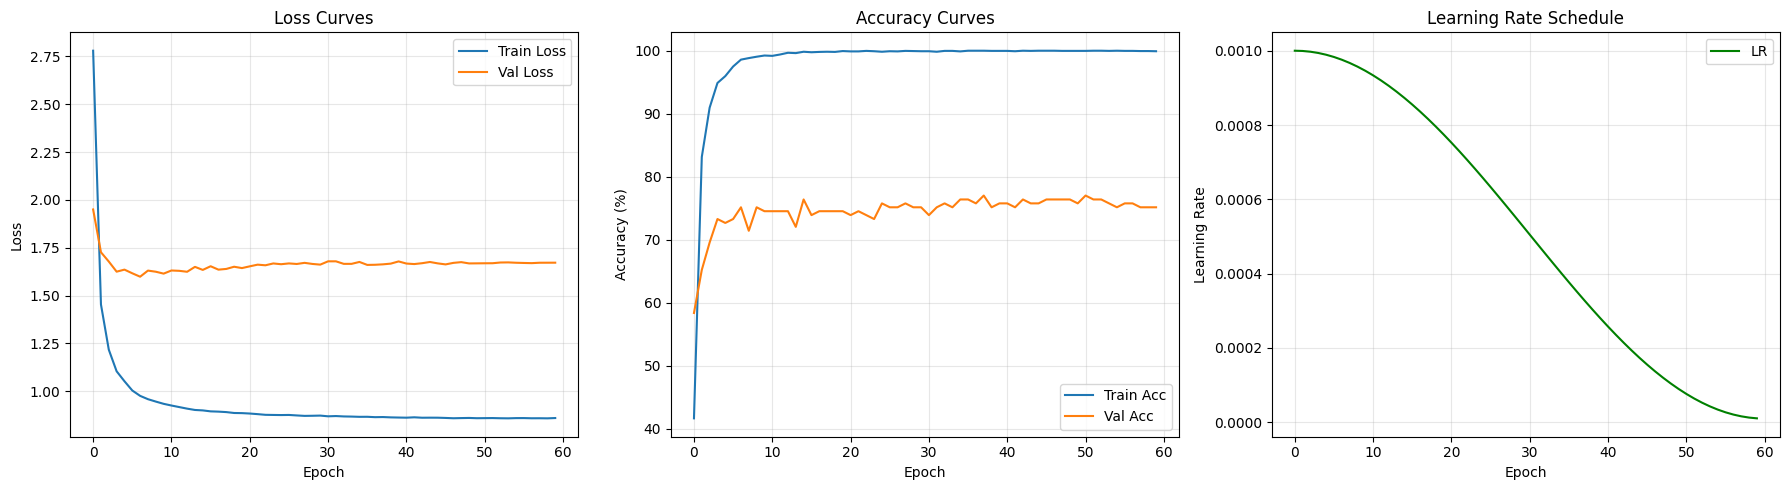

Saved training_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss Curves')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Accuracy Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='green', label='LR')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate'); axes[2].set_title('Learning Rate Schedule')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 9. Final Head - Retrain on ALL Data

After validating the recipe, the head is retrained on every cached feature vector (no holdout) for the final submission model.

In [10]:
head_final = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(FEAT_DIM, NUM_CLASSES)).to(device)
optimizer_f = optim.AdamW(head_final.parameters(), lr=HEAD_LR, weight_decay=HEAD_WD)
scheduler_f = optim.lr_scheduler.CosineAnnealingLR(optimizer_f, T_max=HEAD_EPOCHS, eta_min=1e-5)

full_ds = TensorDataset(train_feats, train_labels)
full_dl = DataLoader(full_ds, batch_size=HEAD_BATCH, shuffle=True)

for epoch in range(HEAD_EPOCHS):
    head_final.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in full_dl:
        xb, yb = xb.to(device), yb.to(device)
        out = head_final(xb)
        loss = criterion(out, yb)
        optimizer_f.zero_grad()
        loss.backward()
        optimizer_f.step()
        running_loss += loss.item() * xb.size(0)
        correct += out.argmax(1).eq(yb).sum().item()
        total += yb.size(0)
    scheduler_f.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:2d}/{HEAD_EPOCHS}] Loss: {running_loss/total:.4f} Acc: {100.0*correct/total:.1f}%')

torch.save(head_final.state_dict(), MODEL_SAVE_PATH)
print(f'Final head saved to {MODEL_SAVE_PATH}')

Epoch [10/60] Loss: 0.9364 Acc: 99.2%
Epoch [20/60] Loss: 0.8910 Acc: 99.7%
Epoch [30/60] Loss: 0.8777 Acc: 99.8%
Epoch [40/60] Loss: 0.8678 Acc: 100.0%
Epoch [50/60] Loss: 0.8651 Acc: 100.0%
Epoch [60/60] Loss: 0.8634 Acc: 100.0%
Final head saved to best_vit_model.pth


## 10. Test Predictions with TTA

Test features are extracted under two deterministic views (center crop and horizontal flip) and the softmax probabilities are averaged.

In [11]:
head_final.eval()

test_view_transforms = [center_tf, flip_tf][:TEST_VIEWS]

all_probs = {}
for v, tf in enumerate(test_view_transforms):
    feats, fnames = extract_features(TestDataset, TEST_DIR, tf, is_test=True)
    with torch.no_grad():
        probs = torch.softmax(head_final(feats.to(device)), dim=1).cpu()
    for fname, p in zip(fnames, probs):
        if fname not in all_probs:
            all_probs[fname] = p
        else:
            all_probs[fname] += p
    print(f'TTA view {v+1}/{len(test_view_transforms)} done.')

predictions = {fname: int(p.argmax()) for fname, p in all_probs.items()}
print(f'\nGenerated predictions for {len(predictions)} test images.')

Loaded 1036 test images
TTA view 1/2 done.
Loaded 1036 test images
TTA view 2/2 done.

Generated predictions for 1036 test images.


In [12]:
rows = [{'ID': fname, 'Label': label} for fname, label in predictions.items()]
submission_df = pd.DataFrame(rows)
submission_df['_sort'] = submission_df['ID'].apply(lambda x: int(os.path.splitext(x)[0]))
submission_df = submission_df.sort_values('_sort').drop(columns='_sort').reset_index(drop=True)

submission_df.to_csv('submission.csv', index=False)
print(f'Saved submission.csv with {len(submission_df)} rows')
print(submission_df.head(10))

Saved submission.csv with 1036 rows
      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     28
8  8.jpg     71
9  9.jpg     65


---
## Summary

| Component | Choice | Rationale |
|-----------|--------|----------|
| **Model** | ViT-B/16, frozen backbone | SWAG features are strong enough that a frozen extractor avoids few-shot overfitting entirely |
| **Pretrained weights** | IMAGENET1K_SWAG_E2E_V1 (384x384) | SWAG trained on 3.6B images, 85.3% ImageNet top-1 |
| **Image size** | 384x384 | Matches SWAG pretraining resolution for ViT-B |
| **Feature caching** | 4 augmented views per training image | Multiplies effective training data at zero backprop cost |
| **Head** | Dropout(0.3) - Linear(768, 100) | Minimal trainable parameters (~77K) for ~10 imgs/class |
| **Optimizer** | AdamW, lr 1e-3, wd 1e-3 | Standard recipe for linear probing |
| **Scheduler** | CosineAnnealingLR | Smooth decay over 60 epochs |
| **Loss** | CrossEntropy + label smoothing (0.1) | Prevents overconfident predictions |
| **Validation** | 15% image-level split | Views of the same image never straddle the split |
| **Inference** | 2-view TTA, softmax-averaged | Center crop + horizontal flip |